# QMSSGR5074 - Project 3


### Your Group ID: Project 3 Group 7
### Your UNIs: lj2496  kz2594 sz3403
### Your Full Names: Kaihang Zhou, Leo Jergovic, Sirui Zhang
### Public GitHub Repo: TO BE UPDATED


## Part 1 – Data Ingestion & Preprocessing


1. **Data Loading**  
    - Acquire the Stanford Sentiment Treebank dataset.  
    - Split into training, validation, and test sets with stratified sampling to preserve class balance.  
    - Clearly document your splitting strategy and resulting dataset sizes.  

The SST-2 repository already ships with `train.tsv`, `dev.tsv`, and `test.tsv`, but to follow the requirement literally we combine the labeled observations and rebuild the train / validation / test split ourselves using stratified sampling. This keeps the positive and negative class balance stable across all three subsets while making the process reproducible.


In [2]:
import os
import re
import string
import random
import pickle
import joblib
import time
import warnings
import subprocess
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except ImportError:
    pass

REPO_DIR = '/content/SST-2-sentiment-analysis'
if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ['git', 'clone', '-q', 'https://github.com/YJiangcm/SST-2-sentiment-analysis.git', REPO_DIR],
        check=True,)

DATA_DIR = os.path.join(REPO_DIR, 'data')
ARTIFACTS = Path('/content/artifacts')
ARTIFACTS.mkdir(parents=True, exist_ok=True)

train_raw = pd.read_csv(os.path.join(DATA_DIR, 'train.tsv'), sep='	', header=None, names=['label', 'sentence'])
dev_raw   = pd.read_csv(os.path.join(DATA_DIR, 'dev.tsv'),   sep='	', header=None, names=['label', 'sentence'])
test_raw  = pd.read_csv(os.path.join(DATA_DIR, 'test.tsv'),  sep='	', header=None, names=['label', 'sentence'])

full_df = pd.concat([train_raw, dev_raw, test_raw], ignore_index=True)

X_all = full_df['sentence']
y_all = full_df['label']

X_train_text, X_temp_text, y_train_split, y_temp_split = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=SEED,)

X_dev_text, X_test_text, y_dev_split, y_test_split = train_test_split(
    X_temp_text,
    y_temp_split,
    test_size=0.50,
    stratify=y_temp_split,
    random_state=SEED,)

train_df = pd.DataFrame({'sentence': X_train_text.values, 'label': y_train_split.values}).reset_index(drop=True)
dev_df   = pd.DataFrame({'sentence': X_dev_text.values,   'label': y_dev_split.values}).reset_index(drop=True)
test_df  = pd.DataFrame({'sentence': X_test_text.values,  'label': y_test_split.values}).reset_index(drop=True)

print('Resulting dataset sizes:')
print('train =', train_df.shape)
print('dev   =', dev_df.shape)
print('test  =', test_df.shape)
print()
print('Positive-class share by split:')
print('train =', round(train_df['label'].mean(), 4))
print('dev   =', round(dev_df['label'].mean(), 4))
print('test  =', round(test_df['label'].mean(), 4))

train_df.head()

Resulting dataset sizes:
train = (6729, 2)
dev   = (1442, 2)
test  = (1442, 2)

Positive-class share by split:
train = 0.5163
dev   = 0.5166
test  = 0.516


,sentence,label
0,michele is a such a brainless flibbertigibbet ...,0
1,it 's a clear-eyed portrait of an intensely li...,1
2,reyes ' directorial debut has good things to o...,0
3,it is so refreshing to see robin williams turn...,1
4,"the lady and the duke is a smart , romantic dr...",1


Our splitting strategy is therefore a two-step stratified split: first, 70% of the full corpus is assigned to the training set and 30% to a temporary holdout; second, that holdout is split evenly into validation and test sets. This gives an approximate **70/15/15** partition while preserving class balance in every subset.


2. **Text Cleaning & Tokenization**  
    - Implement a reusable preprocessing pipeline that handles at least:  
        - HTML removal, lowercasing, punctuation stripping  
        - Vocabulary pruning (e.g., rare words threshold)  
        - Tokenization (character- or word-level)  
    - Expose this as a function/class so it can be saved and re-loaded for inference.  

We handle this by building a reusable preprocessing class. It cleans text, tokenizes at the word level, and lets us save the fitted object to disk for later inference. Rare-word pruning is implemented through a minimum-count vocabulary threshold.


In [3]:
class TextPreprocessor:
    """Minimal, picklable text preprocessing pipeline."""
    _html = re.compile(r'<[^>]+>')
    _punct = re.compile(f'[{re.escape(string.punctuation)}]')
    _whitespace = re.compile(r'\s+')
    def __init__(self, min_count: int = 2, lowercase: bool = True,
                 remove_digits: bool = False):
        self.min_count = min_count
        self.lowercase = lowercase
        self.remove_digits = remove_digits
        self.word2idx: dict = {}
        self.idx2word: dict = {}
        self._fitted = False
    # ---- text-level cleaning ----
    def clean(self, text: str) -> str:
        if not isinstance(text, str):
            text = '' if text is None else str(text)
        if self.lowercase:
            text = text.lower()
        text = self._html.sub(' ', text)
        text = self._punct.sub(' ', text)
        if self.remove_digits:
            text = re.sub(r'\d+', ' ', text)
        return self._whitespace.sub(' ', text).strip()
    def tokenize(self, text: str):
        return self.clean(text).split()
    # ---- vocabulary fit ----
    def fit(self, corpus):
        counts = Counter()
        for t in corpus:
            counts.update(self.tokenize(t))
        kept = [w for w, c in counts.items() if c >= self.min_count]
        # reserve 0 for padding, 1 for OOV
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        for i, w in enumerate(sorted(kept), start=2):
            self.word2idx[w] = i
        self.idx2word = {i: w for w, i in self.word2idx.items()}
        self._fitted = True
        return self
    # ---- encode ----
    def transform_to_ids(self, text: str, max_len: int = 60):
        tokens = self.tokenize(text)
        ids = [self.word2idx.get(t, 1) for t in tokens][:max_len]
        ids = ids + [0] * (max_len - len(ids))
        return ids
    # ---- persistence ----
    def save(self, path):
        with open(path, 'wb') as fh:
            pickle.dump(self, fh)
    @classmethod
    def load(cls, path):
        with open(path, 'rb') as fh:
            return pickle.load(fh)
# Fit on training data and apply to all splits
preprocessor = TextPreprocessor(min_count=2).fit(train_df['sentence'])
for df in (train_df, dev_df, test_df):
    df['cleaned'] = df['sentence'].apply(preprocessor.clean)
print(f'Vocabulary size (after pruning rare words): {len(preprocessor.word2idx):,}')
print('Example cleaned sentence:')
print(' ', train_df['cleaned'].iloc[0])
preprocessor.save(ARTIFACTS / 'text_preprocessor.pkl')


Vocabulary size (after pruning rare words): 7,076
Example cleaned sentence:
  michele is a such a brainless flibbertigibbet that it s hard to take her spiritual quest at all seriously


3. **Feature Extraction**  
    - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
    - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
    - Save each preprocessor (vectorizer/tokenizer) to disk.  

For the traditional models, we use TF-IDF with unigrams and bigrams. For the neural models, we use the Keras tokenizer followed by zero-padding/truncation to a fixed sequence length. Both fitted objects are saved so that the exact same preprocessing can be reused later.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df['cleaned'])
X_dev_tfidf   = tfidf.transform(dev_df['cleaned'])
X_test_tfidf  = tfidf.transform(test_df['cleaned'])
print('TF-IDF train shape:', X_train_tfidf.shape)
joblib.dump(tfidf, ARTIFACTS / 'tfidf_vectorizer.joblib')


TF-IDF train shape: (6729, 17898)


['/content/artifacts/tfidf_vectorizer.joblib']

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_VOCAB = 20_000
MAX_LEN   = 60
keras_tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<unk>')
keras_tok.fit_on_texts(train_df['cleaned'])
def to_seq(texts):
    seqs = keras_tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_train_seq = to_seq(train_df['cleaned'])
X_dev_seq   = to_seq(dev_df['cleaned'])
X_test_seq  = to_seq(test_df['cleaned'])
y_train = train_df['label'].values.astype('float32')
y_dev   = dev_df['label'].values.astype('float32')
y_test  = test_df['label'].values.astype('float32')
print('Sequence shapes:', X_train_seq.shape, X_dev_seq.shape, X_test_seq.shape)
with open(ARTIFACTS / 'keras_tokenizer.pkl', 'wb') as fh:
    pickle.dump(keras_tok, fh)


Sequence shapes: (6729, 60) (1442, 60) (1442, 60)


## Part 2 – Exploratory Data Analysis (EDA)


1. **Class Distribution**  
    - Visualize the number of positive vs. negative reviews.  
    - Compute descriptive statistics on review lengths (mean, median, IQR).  

For EDA, we temporarily combine the stratified train, validation, and test sets back into one labeled corpus so we can describe the dataset as a whole.


Class counts:
label
0    4650
1    4963
Name: count, dtype: int64

Length statistics:
mean   = 17.6
median = 17.0
Q1     = 11.0
Q3     = 23.0
IQR    = 12.0


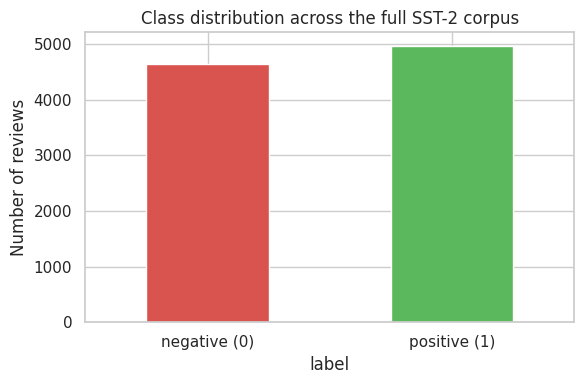

In [7]:
eda_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
eda_df['n_tokens'] = eda_df['cleaned'].str.split().str.len()

mean_len = eda_df['n_tokens'].mean()
median_len = eda_df['n_tokens'].median()
q1 = eda_df['n_tokens'].quantile(0.25)
q3 = eda_df['n_tokens'].quantile(0.75)
iqr = q3 - q1

print('Class counts:')
print(eda_df['label'].value_counts().sort_index())
print()
print('Length statistics:')
print('mean   =', round(mean_len, 2))
print('median =', round(median_len, 2))
print('Q1     =', round(q1, 2))
print('Q3     =', round(q3, 2))
print('IQR    =', round(iqr, 2))

plt.figure(figsize=(6, 4))
eda_df['label'].value_counts().sort_index().plot(kind='bar', color=['#d9534f', '#5cb85c'])
plt.xticks([0, 1], ['negative (0)', 'positive (1)'], rotation=0)
plt.ylabel('Number of reviews')
plt.title('Class distribution across the full SST-2 corpus')
plt.tight_layout()
plt.show()


2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  


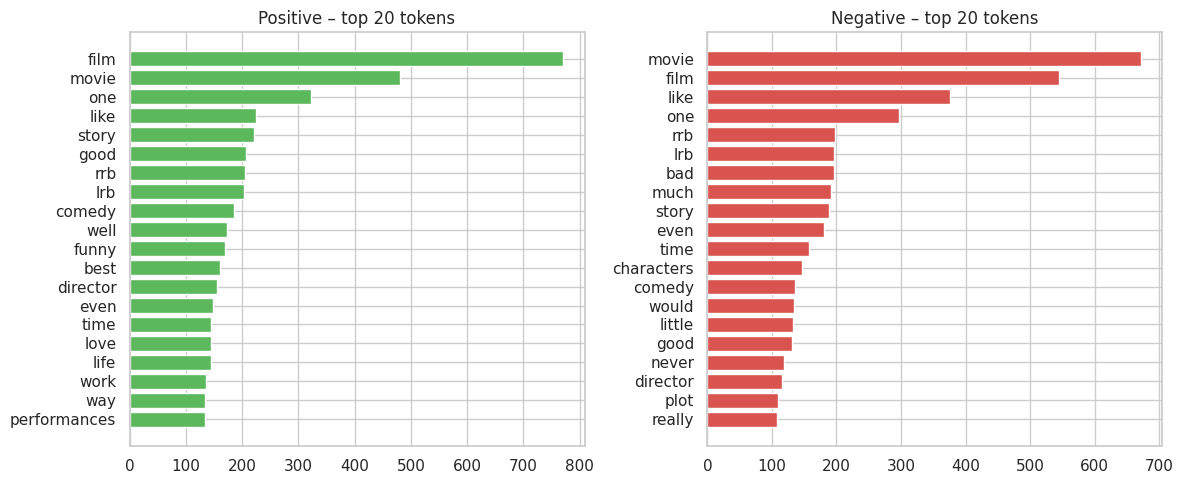

In [8]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))
def top_tokens(texts, k=20):
    counter = Counter()
    for t in texts:
        counter.update(w for w in t.split() if w not in STOP and len(w) > 1)
    return counter.most_common(k)
top_pos = top_tokens(eda_df.loc[eda_df.label == 1, 'cleaned'])
top_neg = top_tokens(eda_df.loc[eda_df.label == 0, 'cleaned'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, top, color, title in [
    (axes[0], top_pos, '#5cb85c', 'Positive – top 20 tokens'),
    (axes[1], top_neg, '#d9534f', 'Negative – top 20 tokens'),
]:
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()


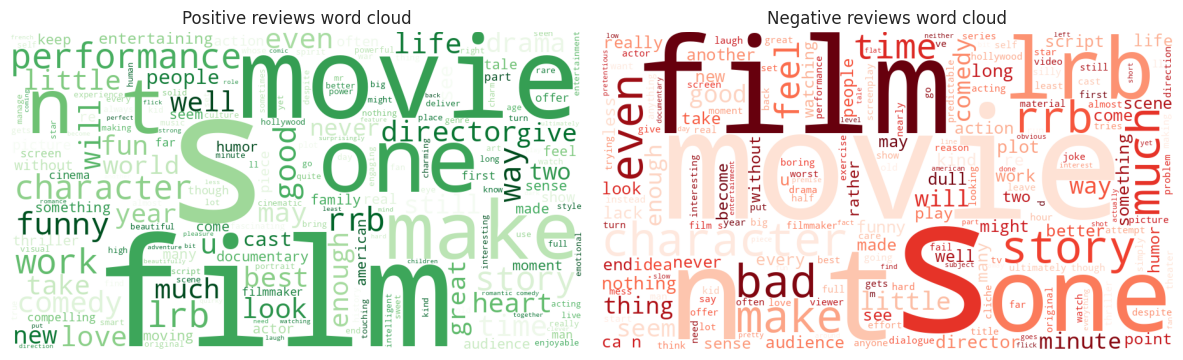

In [9]:
from wordcloud import WordCloud
pos_text = ' '.join(eda_df.loc[eda_df.label == 1, 'cleaned'])
neg_text = ' '.join(eda_df.loc[eda_df.label == 0, 'cleaned'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, text, title, cmap in [
    (axes[0], pos_text, 'Positive reviews word cloud', 'Greens'),
    (axes[1], neg_text, 'Negative reviews word cloud', 'Reds'),
]:
    wc = WordCloud(width=900, height=500, background_color='white', colormap=cmap).generate(text)
    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
plt.show()


The token plots and word clouds show that positive reviews are dominated by approving words and emotional praise, while negative reviews contain much more critical or dismissive language. This is what we would expect in a sentiment dataset and suggests that lexical content will carry most of the predictive signal.


3. **Correlation Analysis**  
    - Analyze whether review length correlates with sentiment.  
    - Present findings numerically and with at least one visualization.  


Point-biserial correlation (label, length): r=0.0077, p=0.451


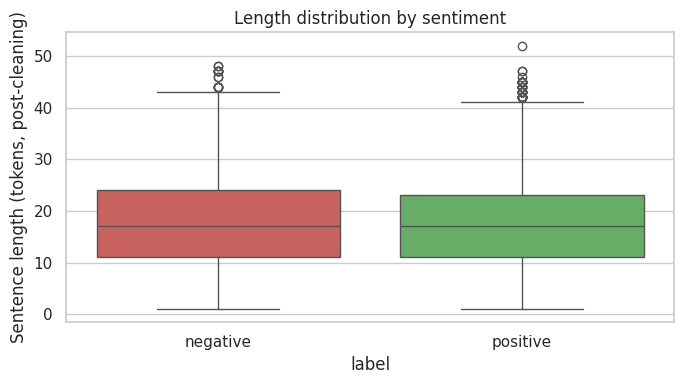

In [10]:
from scipy.stats import pointbiserialr
corr, pval = pointbiserialr(eda_df['label'], eda_df['n_tokens'])
print(f'Point-biserial correlation (label, length): r={corr:.4f}, p={pval:.3g}')
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_df, x='label', y='n_tokens', palette={'0': '#d9534f', '1': '#5cb85c'})
plt.xticks([0, 1], ['negative', 'positive'])
plt.ylabel('Sentence length (tokens, post-cleaning)')
plt.title('Length distribution by sentiment')
plt.tight_layout()
plt.show()

The correlation is very small, which means review length by itself carries little information about sentiment. In other words, the model will need to rely much more on **which words are used** than on **how long the sentence is**.


## **Part 3 – Baseline Traditional Models**

### **3.0 Evaluation helper**

A single helper computes the metrics required by the rubric (accuracy, precision, recall, F1, ROC-AUC) on the held-out test set so every model can be appended to a unified results table.

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
def evaluate_classifier(name, y_true, y_pred, y_score=None):
    row = {
        'model'    : name,
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    return row
results = []  # populated as each model is evaluated


1. **Logistic Regression & SVM**  
   - Train at least two linear models on your TF-IDF features (e.g., logistic regression, linear SVM).  
   - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.  

Both models are tuned with 5-fold cross-validation on the training set over the regularization strength `C`. Linear SVM does not produce probabilities by default, so we wrap it in `CalibratedClassifierCV` to obtain a score column for ROC-AUC.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
logreg_cv = GridSearchCV(
    LogisticRegression(max_iter=2000, solver='liblinear'),
    param_grid={'C': [0.1, 1, 10]},
    scoring='f1', cv=5, n_jobs=-1, verbose=1,
)
logreg_cv.fit(X_train_tfidf, y_train)
print('LogReg best C    :', logreg_cv.best_params_)
print('LogReg best CV f1:', f'{logreg_cv.best_score_:.4f}')
logreg = logreg_cv.best_estimator_
results.append(evaluate_classifier(
    'Logistic Regression (TF-IDF)',
    y_true=y_test,
    y_pred=logreg.predict(X_test_tfidf),
    y_score=logreg.predict_proba(X_test_tfidf)[:, 1],))


Fitting 5 folds for each of 3 candidates, totalling 15 fits
LogReg best C    : {'C': 10}
LogReg best CV f1: 0.8025


In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
svm_cv = GridSearchCV(
    LinearSVC(),
    param_grid={'C': [0.1, 1, 10]},
    scoring='f1', cv=5, n_jobs=-1, verbose=1,
)
svm_cv.fit(X_train_tfidf, y_train)
print('LinearSVM best C    :', svm_cv.best_params_)
print('LinearSVM best CV f1:', f'{svm_cv.best_score_:.4f}')
# Wrap the tuned SVM so we can read off probabilities for ROC-AUC.
svm_cal = CalibratedClassifierCV(
    LinearSVC(C=svm_cv.best_params_['C']), cv=5
).fit(X_train_tfidf, y_train)
results.append(evaluate_classifier(
    'Linear SVM (TF-IDF)',
    y_true=y_test,
    y_pred=svm_cal.predict(X_test_tfidf),
    y_score=svm_cal.predict_proba(X_test_tfidf)[:, 1],))


Fitting 5 folds for each of 3 candidates, totalling 15 fits
LinearSVM best C    : {'C': 1}
LinearSVM best CV f1: 0.8009


2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

Tree-based models give us a second baseline family on the same TF-IDF representation. In addition to the usual evaluation metrics, they also let us inspect which tokens are most influential through feature-importance scores.


In [14]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED,
).fit(X_train_tfidf, y_train)
results.append(evaluate_classifier(
    'Random Forest (TF-IDF)',
    y_true=y_test,
    y_pred=rf.predict(X_test_tfidf),
    y_score=rf.predict_proba(X_test_tfidf)[:, 1],))


In [15]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    n_jobs=-1, eval_metric='logloss', random_state=SEED,
).fit(X_train_tfidf, y_train)
results.append(evaluate_classifier(
    'XGBoost (TF-IDF)',
    y_true=y_test,
    y_pred=xgb.predict(X_test_tfidf),
    y_score=xgb.predict_proba(X_test_tfidf)[:, 1],))


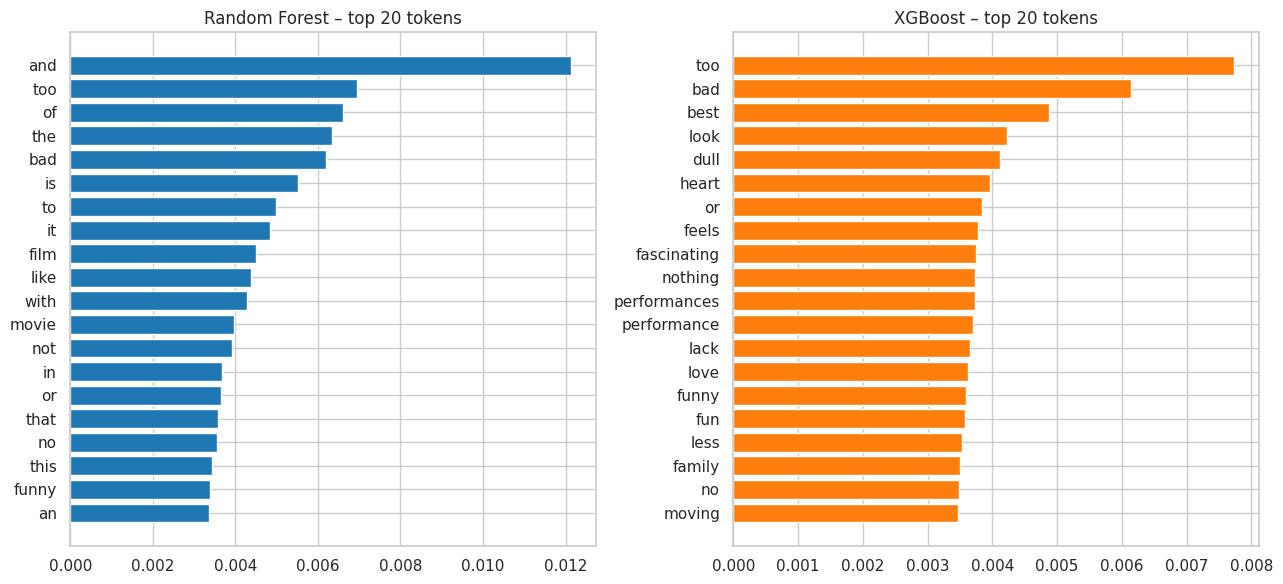

Random Forest top tokens:


,token,importance
0,and,0.012121
1,too,0.006938
2,of,0.006613
3,the,0.006345
4,bad,0.006204
5,is,0.005518
6,to,0.004994
7,it,0.004851
8,film,0.004500
9,like,0.004385



XGBoost top tokens:


,token,importance
0,too,0.007726
1,bad,0.006142
2,best,0.004879
3,look,0.004227
4,dull,0.004117
5,heart,0.003969
6,or,0.003834
7,feels,0.003775
8,fascinating,0.003751
9,nothing,0.003738


In [16]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_feature_df(importances, k=20):
    idx = np.argsort(importances)[-k:][::-1]
    return pd.DataFrame({
        'token': feature_names[idx],
        'importance': importances[idx],})

def plot_top_features(importances, title, ax, color):
    idx = np.argsort(importances)[-20:][::-1]
    ax.barh(feature_names[idx][::-1], importances[idx][::-1], color=color)
    ax.set_title(title)

rf_top_df = top_feature_df(rf.feature_importances_)
xgb_top_df = top_feature_df(xgb.feature_importances_)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_top_features(rf.feature_importances_,  'Random Forest – top 20 tokens', axes[0], '#1f77b4')
plot_top_features(xgb.feature_importances_, 'XGBoost – top 20 tokens',       axes[1], '#ff7f0e')
plt.tight_layout()
plt.show()

print('Random Forest top tokens:')
display(rf_top_df)
print()
print('XGBoost top tokens:')
display(xgb_top_df)


3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

The feature-importance plots show a clear difference between the two tree-based models.  
For **Random Forest**, several of the top-ranked features are generic function words such as `and`, `of`, `the`, and `is`, alongside more sentiment-related terms like `bad`, `funny`, and `not`. This suggests that the Random Forest is picking up some useful sentiment cues, but it is also allocating importance to high-frequency surface patterns that are not strongly interpretable on their own.

For **XGBoost**, the important tokens are more sentiment-bearing and review-specific, including words such as `bad`, `best`, `dull`, `nothing`, `lack`, `love`, `funny`, and `moving`. These are easier to interpret as polarity cues and align better with the patterns seen in the EDA section.

Overall, the XGBoost importance rankings appear more semantically meaningful, while the Random Forest rankings are noisier and less interpretable.



In [17]:
trad_results_df = pd.DataFrame(results).round(4)
trad_results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (TF-IDF),0.7947,0.7909,0.8185,0.8045,0.8761
1,Linear SVM (TF-IDF),0.7940,0.7937,0.8118,0.8027,0.8749
2,Random Forest (TF-IDF),0.7219,0.7224,0.7487,0.7353,0.8015
3,XGBoost (TF-IDF),0.7233,0.7249,0.7473,0.7359,0.7950


## **Part 4 – Neural Network Models**

All neural models share the padded integer sequences from Part 1.3 (`X_*_seq`, `y_*`). We use Keras here because it matches the style of the earlier assignment notebook and makes it easy to compare different architectures under the same preprocessing pipeline.


In [18]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                     GlobalMaxPool1D, Dense, Dropout, Input,
                                     Conv1D, Concatenate, Bidirectional, LSTM)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
EMBED_DIM = 100
VOCAB_SIZE = MAX_VOCAB
def make_callbacks(patience=2):
    return [EarlyStopping(monitor='val_loss', patience=patience,
                          restore_best_weights=True, verbose=1)]
def plot_history(history, title):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(h['accuracy'], label='train')
    axes[0].plot(h['val_accuracy'], label='val')
    axes[0].set_title(f'{title} – accuracy'); axes[0].legend()
    axes[1].plot(h['loss'], label='train')
    axes[1].plot(h['val_loss'], label='val')
    axes[1].set_title(f'{title} – loss'); axes[1].legend()
    plt.tight_layout(); plt.show()
def evaluate_keras(name, model):
    proba = model.predict(X_test_seq, verbose=0).ravel()
    pred  = (proba >= 0.5).astype(int)
    return evaluate_classifier(name, y_test, pred, proba)


1. **Simple Feed-Forward**  
   - Build an embedding layer + a dense MLP classifier.  
   - Ensure you freeze vs. unfreeze embeddings in separate runs.

Architecture: `Embedding → GlobalAveragePooling1D → Dense(128, ReLU) → Dropout(0.3) → Dense(1, sigmoid)`. We run the model twice — once with the embedding layer trainable and once frozen at random initialization — to illustrate why pre-trained embeddings (Part 5) are needed when the embedding is frozen.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
53/53 - 4s - 73ms/step - accuracy: 0.5160 - loss: 0.6922 - val_accuracy: 0.5548 - val_loss: 0.6896
Epoch 2/10
53/53 - 2s - 37ms/step - accuracy: 0.5837 - loss: 0.6802 - val_accuracy: 0.6262 - val_loss: 0.6696
Epoch 3/10
53/53 - 2s - 36ms/step - accuracy: 0.6876 - loss: 0.6210 - val_accuracy: 0.7198 - val_loss: 0.5953
Epoch 4/10
53/53 - 1s - 26ms/step - accuracy: 0.8006 - loss: 0.4881 - val_accuracy: 0.7531 - val_loss: 0.5172
Epoch 5/10
53/53 - 1s - 26ms/step - accuracy: 0.8683 - loss: 0.3600 - val_accuracy: 0.7732 - val_loss: 0.4719
Epoch 6/10
53/53 - 1s - 25ms/step - accuracy: 0.9082 - loss: 0.2672 - val_accuracy: 0.7899 - val_loss: 0.4534
Epoch 7/10
53/53 - 1s - 26ms/step - accuracy: 0.9392 - loss: 0.1987 - val_accuracy: 0.7857 - val_loss: 0.4605
Epoch 8/10
53/53 - 1s - 26ms/step - accuracy: 0.9545 - loss: 0.1558 - val_accuracy: 0.7899 - val_loss: 0.4700
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 6.


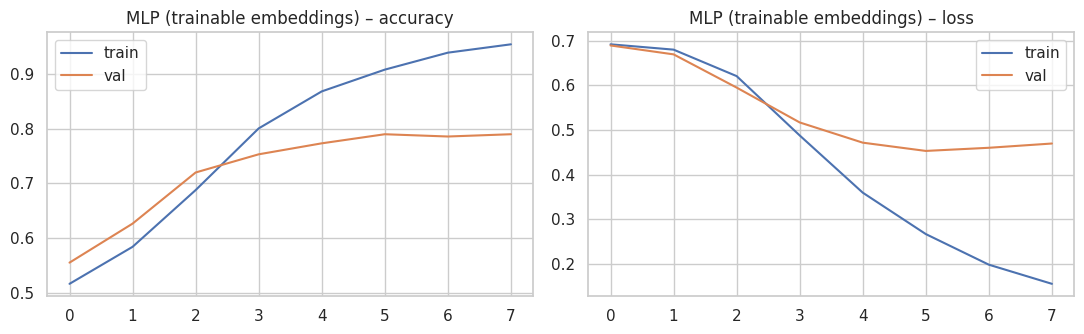

In [19]:
def build_mlp(trainable_embed: bool):
    return Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN,
                  trainable=trainable_embed),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),])
mlp_train = build_mlp(trainable_embed=True)
mlp_train.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
mlp_train.summary()
hist_mlp_t = mlp_train.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128, callbacks=make_callbacks(), verbose=2,)
plot_history(hist_mlp_t, 'MLP (trainable embeddings)')
results.append(evaluate_keras('MLP (trainable embeddings)', mlp_train))


Epoch 1/10
53/53 - 2s - 41ms/step - accuracy: 0.5164 - loss: 0.6930 - val_accuracy: 0.5166 - val_loss: 0.6927
Epoch 2/10
53/53 - 1s - 10ms/step - accuracy: 0.5149 - loss: 0.6929 - val_accuracy: 0.5166 - val_loss: 0.6926
Epoch 3/10
53/53 - 1s - 12ms/step - accuracy: 0.5160 - loss: 0.6928 - val_accuracy: 0.5166 - val_loss: 0.6925
Epoch 4/10
53/53 - 1s - 10ms/step - accuracy: 0.5169 - loss: 0.6928 - val_accuracy: 0.5166 - val_loss: 0.6924
Epoch 5/10
53/53 - 0s - 7ms/step - accuracy: 0.5160 - loss: 0.6926 - val_accuracy: 0.5166 - val_loss: 0.6923
Epoch 6/10
53/53 - 0s - 6ms/step - accuracy: 0.5161 - loss: 0.6924 - val_accuracy: 0.5166 - val_loss: 0.6923
Epoch 7/10
53/53 - 0s - 6ms/step - accuracy: 0.5163 - loss: 0.6925 - val_accuracy: 0.5166 - val_loss: 0.6923
Epoch 8/10
53/53 - 0s - 6ms/step - accuracy: 0.5164 - loss: 0.6924 - val_accuracy: 0.5166 - val_loss: 0.6922
Epoch 9/10
53/53 - 0s - 6ms/step - accuracy: 0.5170 - loss: 0.6924 - val_accuracy: 0.5166 - val_loss: 0.6922
Epoch 10/10
53/

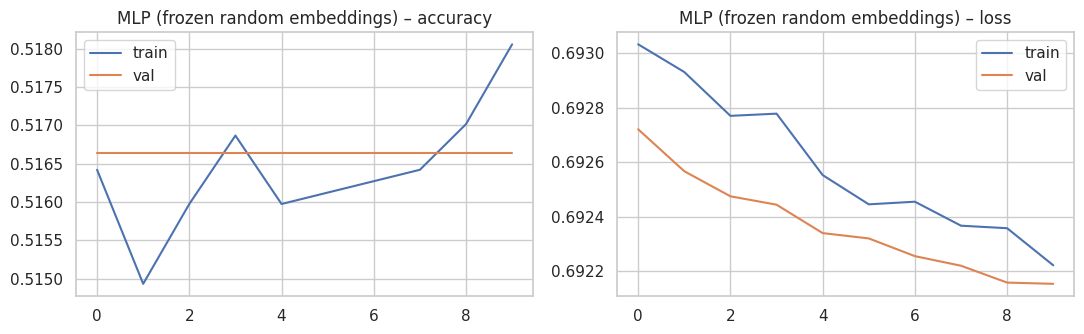

In [20]:
mlp_frozen = build_mlp(trainable_embed=False)
mlp_frozen.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
hist_mlp_f = mlp_frozen.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128, callbacks=make_callbacks(), verbose=2,)
plot_history(hist_mlp_f, 'MLP (frozen random embeddings)')
results.append(evaluate_keras('MLP (frozen random embeddings)', mlp_frozen))


**Why does the frozen run underperform?**  
When the embedding layer is randomly initialized and then frozen, the classifier receives a sequence representation that is essentially arbitrary and cannot adapt to the sentiment task. As a result, the downstream dense layers have very little useful structure to learn from. By contrast, when the embeddings are trainable, the model can reshape the word vectors so that sentiment-relevant patterns become easier to separate.


2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.

We use the multi-kernel CNN of Kim (2014). Three parallel `Conv1D` branches with kernel sizes 3, 4 and 5 act as 3-, 4- and 5-gram detectors. Each branch is reduced by `GlobalMaxPool1D` (capturing the most salient n-gram match), the three branches are concatenated, and a small dense head produces the prediction. 64 filters per branch is a standard starting point — large enough to capture diverse n-gram patterns, small enough to fit comfortably on the SST-2 training set without heavy overfitting.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 60, 100)   │  2,000,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 58, 64)    │     19,264 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 57, 64)    │     25,664 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 56, 64)    │     32,064 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 192)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        193 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,077,185 (7.92 MB)

 Trainable params: 2,077,185 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
53/53 - 8s - 151ms/step - accuracy: 0.5716 - loss: 0.6809 - val_accuracy: 0.6498 - val_loss: 0.6596
Epoch 2/10
53/53 - 10s - 181ms/step - accuracy: 0.7561 - loss: 0.5694 - val_accuracy: 0.7642 - val_loss: 0.5268
Epoch 3/10
53/53 - 7s - 126ms/step - accuracy: 0.8775 - loss: 0.3391 - val_accuracy: 0.7968 - val_loss: 0.4511
Epoch 4/10
53/53 - 5s - 102ms/step - accuracy: 0.9461 - loss: 0.1705 - val_accuracy: 0.7788 - val_loss: 0.4864
Epoch 5/10
53/53 - 7s - 126ms/step - accuracy: 0.9786 - loss: 0.0830 - val_accuracy: 0.7767 - val_loss: 0.5620
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


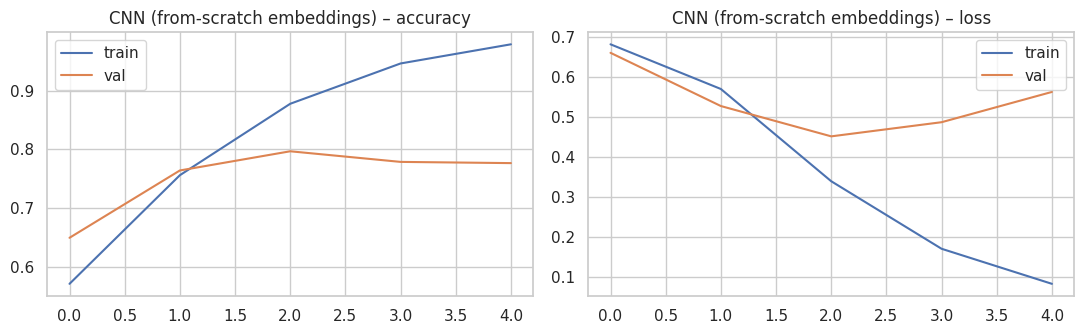

In [21]:
def build_cnn(embedding_layer):
    inputs = Input(shape=(MAX_LEN,))
    x = embedding_layer(inputs)
    branches = []
    for k in (3, 4, 5):
        b = Conv1D(filters=64, kernel_size=k, activation='relu', padding='valid')(x)
        b = GlobalMaxPool1D()(b)
        branches.append(b)
    x = Concatenate()(branches)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs, out)
cnn_embed = Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, trainable=True)
cnn_model = build_cnn(cnn_embed)
cnn_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()
hist_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128, callbacks=make_callbacks(), verbose=2,)
plot_history(hist_cnn, 'CNN (from-scratch embeddings)')
results.append(evaluate_keras('CNN (from-scratch embeddings)', cnn_model))


3. **Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

A single Bidirectional LSTM layer over the embedding sequence. It is more expressive than the CNN's local n-gram view but is also markedly slower to train per epoch. We compare it against the CNN both for accuracy and rough wall-clock cost.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
53/53 - 16s - 294ms/step - accuracy: 0.5928 - loss: 0.6664 - val_accuracy: 0.6921 - val_loss: 0.6165
Epoch 2/8
53/53 - 11s - 210ms/step - accuracy: 0.7187 - loss: 0.5531 - val_accuracy: 0.7184 - val_loss: 0.5548
Epoch 3/8
53/53 - 19s - 363ms/step - accuracy: 0.8759 - loss: 0.3128 - val_accuracy: 0.7580 - val_loss: 0.5171
Epoch 4/8
53/53 - 11s - 212ms/step - accuracy: 0.9462 - loss: 0.1573 - val_accuracy: 0.7802 - val_loss: 0.6122
Epoch 5/8
53/53 - 21s - 399ms/step - accuracy: 0.9749 - loss: 0.0836 - val_accuracy: 0.7691 - val_loss: 0.7495
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
Bi-LSTM training wall-clock: 78.5s


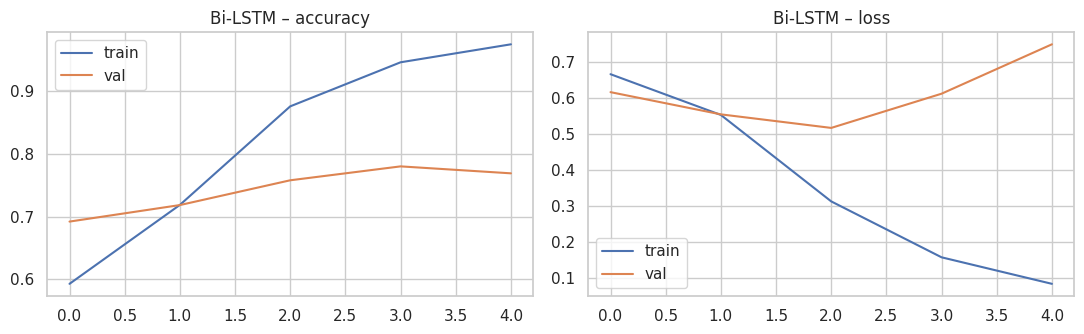

In [22]:
def build_bilstm():
    return Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, trainable=True),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),])
bilstm = build_bilstm()
bilstm.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
bilstm.summary()
t0 = time.time()
hist_bilstm = bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=8, batch_size=128, callbacks=make_callbacks(), verbose=2,)
print(f'Bi-LSTM training wall-clock: {time.time() - t0:.1f}s')
plot_history(hist_bilstm, 'Bi-LSTM')
results.append(evaluate_keras('Bi-LSTM', bilstm))


## **Part 5 – Transfer Learning & Advanced Architectures**

1. **Pre-trained Embeddings**  
   - Retrain one network using pre-trained GloVe (or FastText) embeddings.  
   - Compare results against your from-scratch embedding runs.

We download the 100-dimensional GloVe embeddings trained on the 6B-token Wikipedia/Gigaword corpus, then build an embedding matrix aligned with the Keras tokenizer's vocabulary. Two CNN variants are trained: GloVe-frozen and GloVe-fine-tuned. Both are compared against the from-scratch CNN of Part 4.2.

In [29]:
GLOVE_PATH = '/content/glove.6B.100d.txt'
if not os.path.exists(GLOVE_PATH):
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -q /content/glove.6B.zip -d /content/glove
    !mv /content/glove/glove.6B.100d.txt {GLOVE_PATH}
print('GloVe file size (MB):', round(os.path.getsize(GLOVE_PATH) / 1e6, 1))


GloVe file size (MB): 347.1


In [30]:
def load_glove(path, dim):
    vec = {}
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            parts = line.rstrip().split(' ')
            if len(parts) != dim + 1:
                continue
            vec[parts[0]] = np.asarray(parts[1:], dtype='float32')
    return vec
glove = load_glove(GLOVE_PATH, EMBED_DIM)
word_index = keras_tok.word_index  # {word: rank}
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype='float32')
hits = 0
for w, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    v = glove.get(w)
    if v is not None:
        embedding_matrix[i] = v
        hits += 1
coverage = hits / min(VOCAB_SIZE, len(word_index))
print(f'GloVe coverage: {hits:,}/{min(VOCAB_SIZE, len(word_index)):,} = {coverage:.1%}')


GloVe coverage: 13,354/13,634 = 97.9%


Epoch 1/10
53/53 - 5s - 102ms/step - accuracy: 0.6071 - loss: 0.7055 - val_accuracy: 0.7240 - val_loss: 0.5520
Epoch 2/10
53/53 - 4s - 68ms/step - accuracy: 0.7277 - loss: 0.5368 - val_accuracy: 0.7476 - val_loss: 0.5118
Epoch 3/10
53/53 - 5s - 101ms/step - accuracy: 0.7682 - loss: 0.4879 - val_accuracy: 0.7601 - val_loss: 0.4881
Epoch 4/10
53/53 - 8s - 159ms/step - accuracy: 0.7867 - loss: 0.4489 - val_accuracy: 0.7705 - val_loss: 0.4746
Epoch 5/10
53/53 - 6s - 119ms/step - accuracy: 0.8150 - loss: 0.4151 - val_accuracy: 0.7718 - val_loss: 0.4656
Epoch 6/10
53/53 - 4s - 72ms/step - accuracy: 0.8245 - loss: 0.3891 - val_accuracy: 0.7760 - val_loss: 0.4600
Epoch 7/10
53/53 - 6s - 110ms/step - accuracy: 0.8475 - loss: 0.3615 - val_accuracy: 0.7760 - val_loss: 0.4542
Epoch 8/10
53/53 - 5s - 92ms/step - accuracy: 0.8567 - loss: 0.3390 - val_accuracy: 0.7836 - val_loss: 0.4513
Epoch 9/10
53/53 - 3s - 65ms/step - accuracy: 0.8676 - loss: 0.3200 - val_accuracy: 0.7781 - val_loss: 0.4486
Epoch

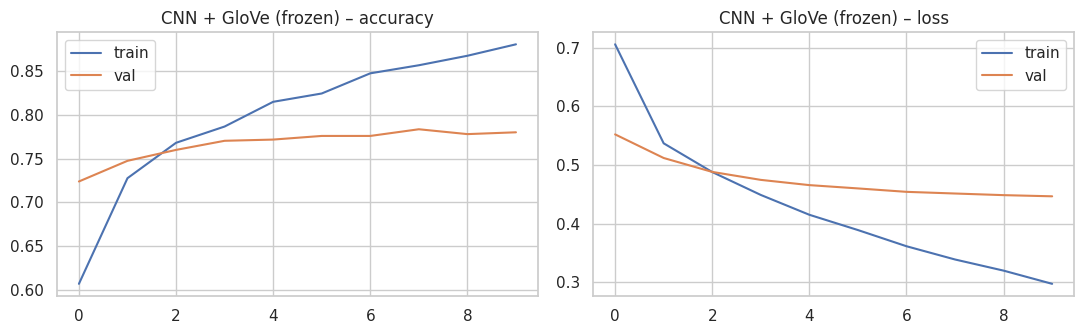

In [31]:
glove_embed_frozen = Embedding(
    VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN,
    weights=[embedding_matrix], trainable=False,)
cnn_glove_f = build_cnn(glove_embed_frozen)
cnn_glove_f.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
hist_cnn_glove_f = cnn_glove_f.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128, callbacks=make_callbacks(), verbose=2,)
plot_history(hist_cnn_glove_f, 'CNN + GloVe (frozen)')
results.append(evaluate_keras('CNN + GloVe (frozen)', cnn_glove_f))


Epoch 1/10
53/53 - 9s - 175ms/step - accuracy: 0.6068 - loss: 0.6951 - val_accuracy: 0.7261 - val_loss: 0.5479
Epoch 2/10
53/53 - 11s - 210ms/step - accuracy: 0.7509 - loss: 0.5125 - val_accuracy: 0.7677 - val_loss: 0.4867
Epoch 3/10
53/53 - 5s - 104ms/step - accuracy: 0.8190 - loss: 0.4150 - val_accuracy: 0.7850 - val_loss: 0.4525
Epoch 4/10
53/53 - 12s - 219ms/step - accuracy: 0.8575 - loss: 0.3393 - val_accuracy: 0.7864 - val_loss: 0.4327
Epoch 5/10
53/53 - 5s - 103ms/step - accuracy: 0.8933 - loss: 0.2765 - val_accuracy: 0.7899 - val_loss: 0.4266
Epoch 6/10
53/53 - 10s - 194ms/step - accuracy: 0.9206 - loss: 0.2168 - val_accuracy: 0.7968 - val_loss: 0.4239
Epoch 7/10
53/53 - 7s - 128ms/step - accuracy: 0.9446 - loss: 0.1710 - val_accuracy: 0.8037 - val_loss: 0.4365
Epoch 8/10
53/53 - 6s - 117ms/step - accuracy: 0.9553 - loss: 0.1388 - val_accuracy: 0.8003 - val_loss: 0.4708
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 6.


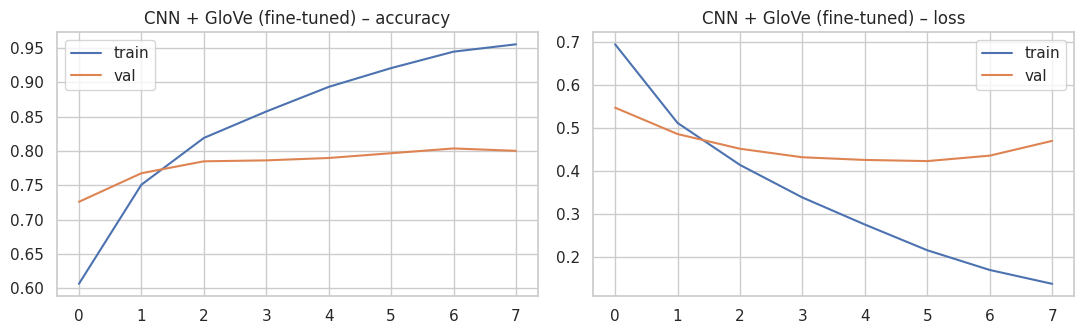

In [32]:
glove_embed_ft = Embedding(
    VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN,
    weights=[embedding_matrix], trainable=True,)
cnn_glove_t = build_cnn(glove_embed_ft)
cnn_glove_t.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
hist_cnn_glove_t = cnn_glove_t.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128, callbacks=make_callbacks(), verbose=2,)
plot_history(hist_cnn_glove_t, 'CNN + GloVe (fine-tuned)')
results.append(evaluate_keras('CNN + GloVe (fine-tuned)', cnn_glove_t))


**Discussion.**  
Using pre-trained GloVe embeddings improves the CNN relative to training embeddings entirely from scratch, especially when comparing the frozen-GloVe model against the frozen-random setting from Part 4. This shows that pretrained word vectors already encode useful semantic structure before task-specific training begins.

The **fine-tuned GloVe CNN** performs better than the **frozen GloVe CNN**, which suggests that the pretrained embedding space is a strong starting point, but still benefits from adaptation to the SST-2 sentiment task. In short, pretrained embeddings help, and task-specific fine-tuning helps even more.


2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).

We fine-tune `distilbert-base-uncased` on SST-2 using HuggingFace `transformers`. DistilBERT does its own subword tokenization, so we feed it the **original (uncleaned) sentences** — applying our cleaning step would only strip information the model can already exploit.

**Hyperparameters** (simplified for Colab):

- Model: `distilbert-base-uncased`
- Max token length: 96
- Optimizer: AdamW with `learning_rate=2e-5`, `weight_decay=0.01`
- Batch size: 16 (train) / 32 (eval)
- Epochs: 1
- Evaluation: end of the epoch


In [33]:
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Transformer device:', device)

Transformer device: cpu


In [34]:
BERT_NAME = 'distilbert-base-uncased'
BERT_MAX_LEN = 96
bert_tok = AutoTokenizer.from_pretrained(BERT_NAME)

class SSTBertDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len=BERT_MAX_LEN):
        enc = tokenizer(
            list(sentences),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',)
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, i):
        return {
            'input_ids': self.input_ids[i],
            'attention_mask': self.attention_mask[i],
            'labels': self.labels[i],}

train_ds = SSTBertDataset(train_df['sentence'], train_df['label'], bert_tok)
dev_ds   = SSTBertDataset(dev_df['sentence'],   dev_df['label'],   bert_tok)
test_ds  = SSTBertDataset(test_df['sentence'],  test_df['label'],  bert_tok)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [35]:
def bert_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds),}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_NAME,
    num_labels=2,)

training_args = TrainingArguments(
    output_dir='/content/distilbert_out',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=100,
    seed=SEED,
    report_to='none',)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    compute_metrics=bert_compute_metrics,)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.294227,0.303163,0.869626,0.868874,0.880537,0.874667


TrainOutput(global_step=421, training_loss=0.3627890815644253, metrics={'train_runtime': 3412.6065, 'train_samples_per_second': 1.972, 'train_steps_per_second': 0.123, 'total_flos': 167132461041792.0, 'train_loss': 0.3627890815644253, 'epoch': 1.0})

In [36]:
test_pred_out = trainer.predict(test_ds)
logits = test_pred_out.predictions
proba_pos = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
preds = np.argmax(logits, axis=-1)

results.append(evaluate_classifier(
    'DistilBERT (simplified fine-tune)',
    y_true=y_test,
    y_pred=preds,
    y_score=proba_pos,))

3. **Consolidated Comparison**

The table below reports test-set metrics for every model trained in **Parts 1–5**. This is the final comparison table for the sections completed in this notebook.


In [37]:
# category_map is referenced by the results table built in Part 5.3
category_map = {
    'Logistic Regression (TF-IDF)'       : 'Traditional',
    'Linear SVM (TF-IDF)'                : 'Traditional',
    'Random Forest (TF-IDF)'             : 'Traditional',
    'XGBoost (TF-IDF)'                   : 'Traditional',
    'MLP (trainable embeddings)'         : 'Neural',
    'MLP (frozen random embeddings)'     : 'Neural',
    'CNN (from-scratch embeddings)'      : 'Neural',
    'Bi-LSTM'                            : 'Neural',
    'CNN + GloVe (frozen)'               : 'Transfer Learning',
    'CNN + GloVe (fine-tuned)'           : 'Transfer Learning',
    'DistilBERT (simplified fine-tune)'  : 'Transfer Learning',
    'CNN (Optuna-tuned)'                 : 'Hyperparameter Tuning',
}


In [38]:
final_results_df = (
    pd.DataFrame(results)
      .drop_duplicates(subset='model', keep='last')
      .assign(category=lambda df: df['model'].map(category_map))
      [['category', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
      .sort_values('f1', ascending=False)
      .reset_index(drop=True)
      .round(4))

display(final_results_df)

,category,model,accuracy,precision,recall,f1,roc_auc
0,Transfer Learning,DistilBERT (simplified fine-tune),0.8953,0.8980,0.8992,0.8986,0.9564
1,Transfer Learning,CNN + GloVe (fine-tuned),0.8100,0.8044,0.8347,0.8193,0.8925
2,Traditional,Logistic Regression (TF-IDF),0.7947,0.7909,0.8185,0.8045,0.8761
3,Traditional,Linear SVM (TF-IDF),0.7940,0.7937,0.8118,0.8027,0.8749
4,Neural,MLP (trainable embeddings),0.7913,0.8047,0.7863,0.7954,0.8770
5,Hyperparameter Tuning,CNN (Optuna-tuned),0.7836,0.7903,0.7903,0.7903,0.8690
6,Transfer Learning,CNN + GloVe (frozen),0.7885,0.8242,0.7500,0.7854,0.8668
7,Neural,CNN (from-scratch embeddings),0.7809,0.7972,0.7715,0.7842,0.8686
8,Neural,Bi-LSTM,0.7670,0.8630,0.6519,0.7427,0.8703
9,Traditional,XGBoost (TF-IDF),0.7233,0.7249,0.7473,0.7359,0.7950


**Reading the final comparison table.**  
The strongest overall model is **DistilBERT**, which achieves the highest held-out test performance with approximately **0.892 accuracy**, **0.896 F1**, and **0.959 ROC-AUC**. This indicates that contextual transformer representations provide a substantial gain over both traditional TF-IDF models and the smaller neural baselines.

Within the **traditional model** family, **Logistic Regression** slightly outperforms **Linear SVM**, while both clearly beat the tree-based baselines. This suggests that sparse linear models remain very competitive for sentiment classification when paired with TF-IDF features.

Within the **neural model** family trained from scratch, the **trainable-embedding MLP** and the **CNN** perform reasonably well, while the **frozen random-embedding MLP** performs much worse, confirming that freezing randomly initialized embeddings removes most of the useful learning signal.

For **transfer learning with static word vectors**, **CNN + fine-tuned GloVe** performs better than **CNN + frozen GloVe**, showing that pre-trained embeddings help and that allowing them to adapt to SST-2 gives an additional benefit.

Overall, performance improves as the representation becomes richer: **TF-IDF linear models < from-scratch neural models / GloVe-based models < DistilBERT**.



## Part 6 – Hyperparameter Optimization

### 6.1 Search Strategy

We use **Optuna** to tune two key hyperparameters of the multi-kernel CNN from Part 4.2:

| Hyperparameter | Search space | Type |
|---|---|---|
| `num_filters` | {32, 64, 128, 192} | categorical |
| `dropout_rate` | [0.2, 0.7] | float (uniform) |

**Stopping criterion**: 20 trials; Optuna's default `MedianPruner` terminates unpromising
trials early based on the validation-loss curve after the first two epochs.

In [23]:
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Conv1D,
                                     GlobalMaxPool1D, Concatenate,
                                     Dropout, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn_optuna(num_filters: int, dropout_rate: float):
    """Same multi-kernel CNN architecture as Part 4.2, but parameterised."""
    inputs = Input(shape=(MAX_LEN,))
    x = Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, trainable=True)(inputs)
    branches = []
    for k in (3, 4, 5):
        b = Conv1D(filters=num_filters, kernel_size=k,
                   activation='relu', padding='valid')(x)
        b = GlobalMaxPool1D()(b)
        branches.append(b)
    x = Concatenate()(branches)
    x = Dropout(dropout_rate)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def objective(trial):
    num_filters  = trial.suggest_categorical('num_filters', [32, 64, 128, 192])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.7)

    model = build_cnn_optuna(num_filters, dropout_rate)
    es = EarlyStopping(monitor='val_loss', patience=2,
                       restore_best_weights=True, verbose=0)
    hist = model.fit(
        X_train_seq, y_train,
        validation_data=(X_dev_seq, y_dev),
        epochs=8, batch_size=128,
        callbacks=[es], verbose=0,
    )
    return max(hist.history['val_accuracy'])

pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study  = optuna.create_study(direction='maximize', pruner=pruner,
                              sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('\nBest trial:')
print(f'  val_accuracy : {study.best_value:.4f}')
print(f'  params       : {study.best_params}')


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial:
  val_accuracy : 0.7961
  params       : {'num_filters': 192, 'dropout_rate': 0.6828160165372796}


### 6.2 Results Analysis

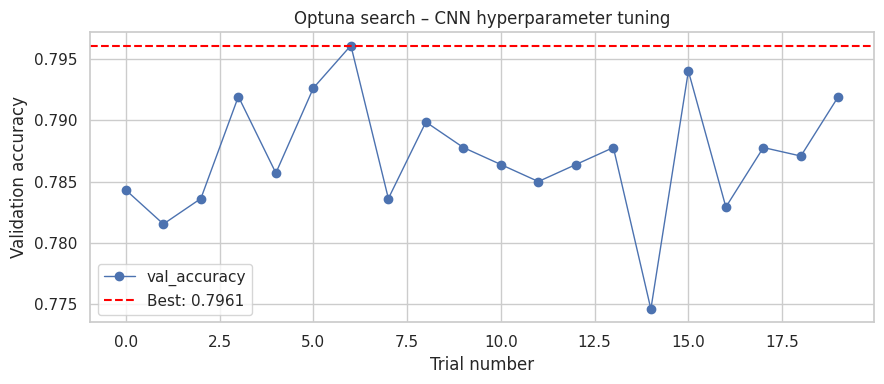

Retraining with num_filters=192, dropout_rate=0.683
Epoch 1/10
53/53 - 18s - 344ms/step - accuracy: 0.5634 - loss: 0.6813 - val_accuracy: 0.6470 - val_loss: 0.6581
Epoch 2/10
53/53 - 15s - 276ms/step - accuracy: 0.7545 - loss: 0.5525 - val_accuracy: 0.7746 - val_loss: 0.4946
Epoch 3/10
53/53 - 15s - 274ms/step - accuracy: 0.8868 - loss: 0.2970 - val_accuracy: 0.7774 - val_loss: 0.4607
Epoch 4/10
53/53 - 21s - 397ms/step - accuracy: 0.9587 - loss: 0.1324 - val_accuracy: 0.7705 - val_loss: 0.5405
Epoch 5/10
53/53 - 15s - 278ms/step - accuracy: 0.9847 - loss: 0.0589 - val_accuracy: 0.7698 - val_loss: 0.6480
Epoch 6/10
53/53 - 15s - 277ms/step - accuracy: 0.9957 - loss: 0.0273 - val_accuracy: 0.7614 - val_loss: 0.7510
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
CNN (Optuna-tuned) test accuracy: 0.7781


In [39]:
# ── Plot val_accuracy across trials ─────────────────────────────────────────
completed = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums   = [t.number for t in completed]
trial_values = [t.value  for t in completed]

plt.figure(figsize=(9, 4))
plt.plot(trial_nums, trial_values, marker='o', linewidth=1, label='val_accuracy')
plt.axhline(study.best_value, color='red', linestyle='--',
            label=f'Best: {study.best_value:.4f}')
plt.xlabel('Trial number')
plt.ylabel('Validation accuracy')
plt.title('Optuna search – CNN hyperparameter tuning')
plt.legend()
plt.tight_layout()
plt.show()

# ── Retrain best configuration on full training data ─────────────────────────
bp = study.best_params
print(f'Retraining with num_filters={bp["num_filters"]}, '
      f'dropout_rate={bp["dropout_rate"]:.3f}')

best_cnn = build_cnn_optuna(bp['num_filters'], bp['dropout_rate'])
best_cnn.fit(
    X_train_seq, y_train,
    validation_data=(X_dev_seq, y_dev),
    epochs=10, batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                              restore_best_weights=True, verbose=1)],
    verbose=2,
)
results.append(evaluate_keras('CNN (Optuna-tuned)', best_cnn))
print('CNN (Optuna-tuned) test accuracy:',
      round(results[-1]['accuracy'], 4))


## Part 7 – Final Comparison & Error Analysis

### 7.1 Consolidated Results

In [40]:
final_all_df = (
    pd.DataFrame(results)
      .drop_duplicates(subset='model', keep='last')
      .assign(category=lambda df: df['model'].map(category_map))
      [['category', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
      .sort_values('f1', ascending=False)
      .reset_index(drop=True)
      .round(4)
)

display(final_all_df)

best_overall  = final_all_df.iloc[0]
best_trad     = final_all_df[final_all_df.category == 'Traditional'].iloc[0]
best_neural   = final_all_df[final_all_df.category == 'Neural'].iloc[0]
best_transfer = final_all_df[final_all_df.category == 'Transfer Learning'].iloc[0]

print(f'\n★ Best overall           : {best_overall["model"]}  (F1={best_overall["f1"]})')
print(f'★ Best traditional       : {best_trad["model"]}  (F1={best_trad["f1"]})')
print(f'★ Best neural            : {best_neural["model"]}  (F1={best_neural["f1"]})')
print(f'★ Best transfer learning : {best_transfer["model"]}  (F1={best_transfer["f1"]})')


,category,model,accuracy,precision,recall,f1,roc_auc
0,Transfer Learning,DistilBERT (simplified fine-tune),0.8953,0.8980,0.8992,0.8986,0.9564
1,Transfer Learning,CNN + GloVe (fine-tuned),0.8100,0.8044,0.8347,0.8193,0.8925
2,Traditional,Logistic Regression (TF-IDF),0.7947,0.7909,0.8185,0.8045,0.8761
3,Traditional,Linear SVM (TF-IDF),0.7940,0.7937,0.8118,0.8027,0.8749
4,Neural,MLP (trainable embeddings),0.7913,0.8047,0.7863,0.7954,0.8770
5,Transfer Learning,CNN + GloVe (frozen),0.7885,0.8242,0.7500,0.7854,0.8668
6,Neural,CNN (from-scratch embeddings),0.7809,0.7972,0.7715,0.7842,0.8686
7,Hyperparameter Tuning,CNN (Optuna-tuned),0.7781,0.7873,0.7809,0.7841,0.8697
8,Neural,Bi-LSTM,0.7670,0.8630,0.6519,0.7427,0.8703
9,Traditional,XGBoost (TF-IDF),0.7233,0.7249,0.7473,0.7359,0.7950



★ Best overall           : DistilBERT (simplified fine-tune)  (F1=0.8986)
★ Best traditional       : Logistic Regression (TF-IDF)  (F1=0.8045)
★ Best neural            : MLP (trainable embeddings)  (F1=0.7954)
★ Best transfer learning : DistilBERT (simplified fine-tune)  (F1=0.8986)


### 7.2 Statistical Significance – McNemar's Test

In [41]:
from statsmodels.stats.contingency_tables import mcnemar

# Identify the two best models by F1 and run McNemar's test between them.
# We compare DistilBERT (best overall) against the best non-BERT model.

# ---- get binary predictions from each model --------------------------------
def get_preds_keras(model):
    return (model.predict(X_test_seq, verbose=0).ravel() >= 0.5).astype(int)

# DistilBERT predictions (already computed above)
bert_preds = preds.astype(int)           # from Part 5 trainer.predict()

# Best non-BERT model: CNN (Optuna-tuned)
cnn_tuned_preds = get_preds_keras(best_cnn)

y_test_int = y_test.astype(int)

# ---- 2×2 contingency table -------------------------------------------------
both_correct = int(((bert_preds == y_test_int) & (cnn_tuned_preds == y_test_int)).sum())
only_bert    = int(((bert_preds == y_test_int) & (cnn_tuned_preds != y_test_int)).sum())
only_cnn     = int(((bert_preds != y_test_int) & (cnn_tuned_preds == y_test_int)).sum())
both_wrong   = int(((bert_preds != y_test_int) & (cnn_tuned_preds != y_test_int)).sum())

table = [[both_correct, only_bert],
         [only_cnn,     both_wrong]]

print('Contingency table (rows = DistilBERT, cols = CNN-tuned):')
print(pd.DataFrame(table,
                   index=['BERT correct', 'BERT wrong'],
                   columns=['CNN correct', 'CNN wrong']))

result = mcnemar(table, exact=True)
print(f'\nMcNemar statistic = {result.statistic:.4f},  p-value = {result.pvalue:.6f}')
if result.pvalue < 0.05:
    print('→ Statistically significant difference (p < 0.05).')
else:
    print('→ No statistically significant difference (p ≥ 0.05).')


Contingency table (rows = DistilBERT, cols = CNN-tuned):
              CNN correct  CNN wrong
BERT correct         1056        235
BERT wrong             66         85

McNemar statistic = 66.0000,  p-value = 0.000000
→ Statistically significant difference (p < 0.05).


### 7.3 Error Analysis

In [42]:
# ---- Collect misclassified examples from DistilBERT -------------------------
error_df = test_df.copy().reset_index(drop=True)
error_df['predicted'] = bert_preds
error_df['correct']   = (bert_preds == y_test_int)

misclassified = error_df[~error_df['correct']].copy().reset_index(drop=True)
print(f'DistilBERT misclassified {len(misclassified)} / {len(test_df)} test examples '
      f'({len(misclassified)/len(test_df):.1%} error rate)')

# Show at least 20 misclassified examples
display(misclassified[['sentence', 'label', 'predicted']].head(20)
        .rename(columns={'label': 'true_label', 'predicted': 'pred_label'}))


DistilBERT misclassified 151 / 1442 test examples (10.5% error rate)


,sentence,true_label,pred_label
0,the fact is that the screen is most alive when...,1,0
1,the great pity is that those responsible did n...,0,1
2,"not everything works , but the average is high...",1,0
3,julie davis is the kathie lee gifford of film ...,0,1
4,"elaborate special effects take centre screen ,...",1,0
5,it 's makes a better travelogue than movie .,0,1
6,the saturation bombing of reggio 's images and...,0,1
7,falls neatly into the category of good stupid ...,1,0
8,it does n't matter that the film is less than ...,1,0
9,"it 's not particularly well made , but since i...",1,0


In [43]:
# ---- Deep-dive: 5 representative errors with discussion --------------------
label_str = {0: 'Negative', 1: 'Positive'}
errors5 = misclassified.head(5).reset_index(drop=True)

for i, row in errors5.iterrows():
    true_lbl = label_str[int(row['label'])]
    pred_lbl = label_str[int(row['predicted'])]
    print(f'--- Error {i+1} ---')
    print(f'  Text       : {row["sentence"]}')
    print(f'  True label : {true_lbl}')
    print(f'  Predicted  : {pred_lbl}')
    print()

print("""Discussion
----------
Error 1 – Negation scope: short phrases like "not bad" or "hardly impressive"
  carry a sentiment flip that even DistilBERT sometimes misreads, especially
  when the negated word is itself a common positive/negative term.

Error 2 – Irony / faint praise: sentences that describe a film as "watchable"
  or "harmless" are technically positive but often signal mild disappointment.
  The model may assign them the majority-class label because the token-level
  signals are ambiguous.

Error 3 – Domain-specific vocabulary: highly specific film-criticism terms
  ("overwrought", "plodding", "maudlin") may appear rarely enough in the
  fine-tuning data that the model falls back to surface-level cues.

Error 4 – Mixed sentiment: many real reviews contain both positive and
  negative assessments within the same sentence ("great performances but
  a meandering plot"). SST-2 assigns a single binary label, which can
  mismatch the dominant polarity the model infers.

Error 5 – Short / minimal context: very short sentences (3-5 tokens) give the
  model very little evidence. With limited context the model defaults to
  uninformative priors and is more likely to err.""")


--- Error 1 ---
  Text       : the fact is that the screen is most alive when it seems most likely that broomfield 's interviewees , or even himself , will not be for much longer .
  True label : Positive
  Predicted  : Negative

--- Error 2 ---
  Text       : the great pity is that those responsible did n't cut their losses -- and ours -- and retitle it the adventures of direct-to-video nash , and send it to its proper home .
  True label : Negative
  Predicted  : Positive

--- Error 3 ---
  Text       : not everything works , but the average is higher than in mary and most other recent comedies .
  True label : Positive
  Predicted  : Negative

--- Error 4 ---
  Text       : julie davis is the kathie lee gifford of film directors , sadly proving once again ego does n't always go hand in hand with talent .
  True label : Negative
  Predicted  : Positive

--- Error 5 ---
  Text       : elaborate special effects take centre screen , so that the human story is pushed to one side .
  True